# FinanceBench P0-P3: controlled architecture comparison

This is the main results notebook for the frozen financial question-answering experiment. It compares closed-book, dense, hybrid, and reranked-hybrid architectures across retrieval, answer correctness, evidence support, latency, native categories, and paired tests. It reads persisted results only; no pipeline or judge is rerun.

Run the cells in order. The presentation functions live in `scripts/notebook_report.py`, so the saved calculations and this narrative remain separate.

In [10]:
from pathlib import Path
import sys

here = Path.cwd().resolve()
repo = next((path for path in (here, *here.parents) if (path / 'scripts' / 'notebook_report.py').exists()), None)
if repo is None:
    raise FileNotFoundError('Open this notebook inside the finrag-arch-eval repository.')
sys.path.insert(0, str(repo))
from scripts.notebook_report import load_report

report = load_report(repo)  # validates the published artifact hashes
print('Loaded frozen run:', report.run_manifest['run_id'])

Loaded frozen run: financebench-heldout-v1


## 1. Study design and controlled parameters

The study selects an architecture rather than proposing a new RAG method. The corpus and question set were frozen before the common evaluation. The architecture table distinguishes the retrieval changes while showing the shared answer-generation settings.

# Controlled financial RAG architecture comparison

**Research question:** Which retrieval architecture best balances retrieval quality, faithfulness, answer correctness, and latency for financial QA? This is a design-selection study, not a new RAG method.

- Frozen run: `financebench-heldout-v1`; 145 held-out FinanceBench questions answered by each of P0-P3 (580 answers). Five development questions were not in this run.
- Frozen corpus: 24,410 chunks; SHA256 `fa3331599807c8b16ea5ae628b433eb092c4d9cf8b407f043e0cb578f6ad62ca`. Dense model: `intfloat/e5-base-v2` (768 dimensions); BM25 tokenizer: `financial_regex_v1`.
- Shared answer model: `gpt-4o-mini`; output limit: 256 tokens; temperature: API default (unset). P1-P3 share one RAG prompt and final context size of 5.
- The raw run, evaluation tables, figures, and tables are persisted. This notebook only reads them.

## P0-P3 architecture and controlled parameters

P0 is closed-book. P1 adds dense retrieval. P2 adds BM25 with RRF. P3 reranks hybrid candidates with a cross-encoder. All four use the same answer model and output limit; P1-P3 share the RAG prompt and final context size.

,architecture,retrieval_design,dense_candidate_k,bm25_candidate_k,fusion_method,rrf_k,fusion_candidate_k,reranker_model,reranker_max_length,reranker_window_overlap,reranker_batch_size,final_context_k,llm_model,generation_max_output_tokens,temperature_policy,prompt_policy
0,P0,closed_book,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,gpt-4o-mini,256,API default (unset),closed_book
1,P1,dense,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,gpt-4o-mini,256,API default (unset),shared_rag_p1_p3
2,P2,hybrid_rrf,10.0,10.0,RRF,60.0,5.0,NaN,NaN,NaN,NaN,5,gpt-4o-mini,256,API default (unset),shared_rag_p1_p3
3,P3,hybrid_rrf_cross_encoder,20.0,20.0,RRF,60.0,20.0,cross-encoder/ms-marco-MiniLM-L6-v2,512.0,64.0,32.0,5,gpt-4o-mini,256,API default (unset),shared_rag_p1_p3


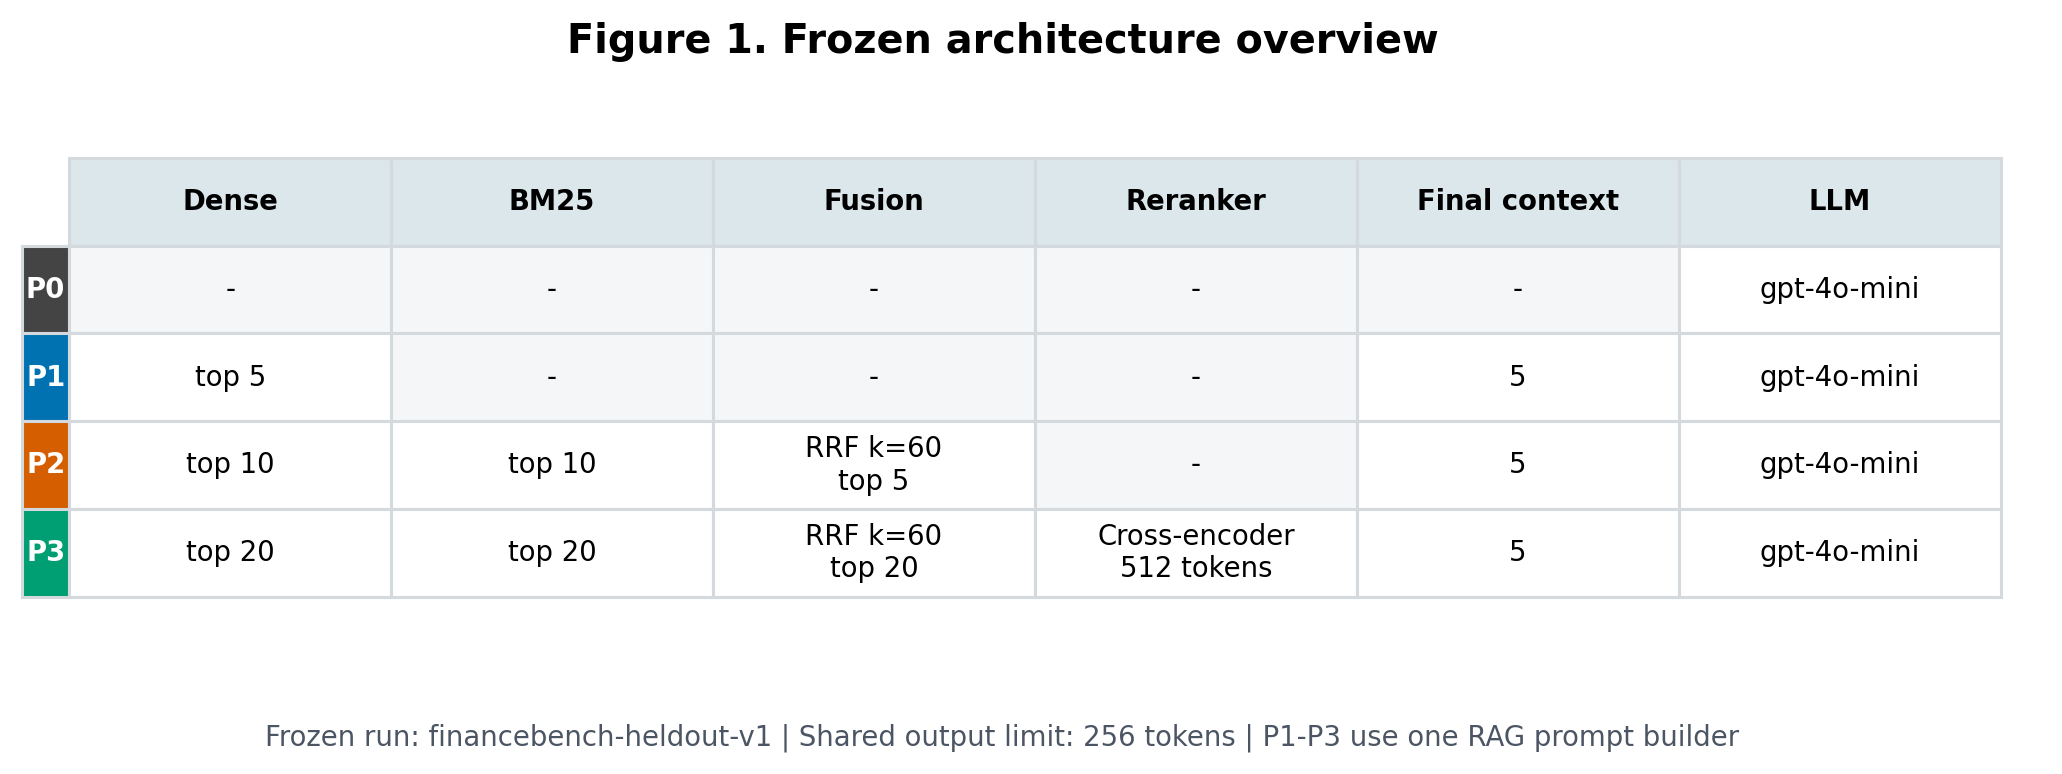

In [2]:
report.show('study')
report.show('architectures')

## 2. Evaluation definitions and overall results

These metrics have different denominators and meanings. P0 has no retrieval/context score. An abstention does not count as zero faithfulness. The overall table keeps those NA cells and the scored-answer counts visible.

In [3]:
report.show('metrics')
report.show('overall')

## Evaluation definitions

Retrieval is evaluated at the annotated `(document, page)` level for P1-P3 only. Strict answer-overlap scores, model-assisted evidence support, and recorded latency answer different questions. Blank/NA is inapplicable or unscored, never zero.

,Metric,Applies to,Definition
0,Hit@1/3/5,P1-P3,Binary: any annotated gold evidence page in final top-k chunks.
1,Recall@5,P1-P3,Unique annotated gold pages in final top 5 / total annotated gold pages.
2,MRR@5,P1-P3,Reciprocal rank of the first annotated gold page in final top 5; otherwise 0.
3,Exact match,P0-P3,Normalized answer-string equality; strict surface metric.
4,Token F1,P0-P3,Bag-of-token overlap with the gold answer after fixed normalization.
5,Numeric accuracy,P0-P3; gold-numeric answers,Matched gold numeric entities / gold numeric entities; corrected v2 extractor.
6,Numeric precision / F1,P0-P3; applicable answers,Precision penalizes extra generated numeric entities; F1 combines precision and recall.
7,Context faithfulness,P1-P3; scored answers,"Supported factual answer units / all factual units, against actual final retrieved chunks."
8,Gold-evidence support,P0-P3; scored answers,Same unit measure against FinanceBench annotated evidence.
9,Hallucination,P0-P3 where support applies,One minus the corresponding support score; not defined for an answer without factual units.


## Overall held-out results

This is the central comparison table. Support scores are conditional on scored factual units; the relevant denominator and exact abstentions are shown beside each rate.

,architecture,question_count,hit_at_5,recall_at_5,mrr_at_5,exact_match,token_f1,numeric_accuracy,numeric_applicable_n,context_faithfulness,context_hallucination,context_scored_n,gold_evidence_support,gold_evidence_hallucination,gold_scored_n,exact_abstention_count,exact_abstention_rate,total_latency_mean_ms,total_latency_median_ms,total_latency_std_ms
0,P0,145,NaN,NaN,NaN,0.007,0.172,0.056,112,NaN,NaN,0,0.583,0.417,112,0,0.000,2073.983,1916.470,1005.903
1,P1,145,0.400,0.362,0.221,0.014,0.159,0.182,112,0.850,0.150,85,0.636,0.364,83,58,0.400,1932.881,1794.853,852.527
2,P2,145,0.317,0.290,0.174,0.007,0.166,0.190,112,0.820,0.180,80,0.621,0.379,81,63,0.434,2245.601,2176.371,777.457
3,P3,145,0.400,0.369,0.284,0.007,0.170,0.176,112,0.832,0.168,86,0.652,0.348,85,58,0.400,5632.504,5618.543,902.969


## 3. Retrieval and answer correctness

Retrieval is evaluated for P1-P3 using FinanceBench's annotated document/page evidence. Answer correctness uses strict surface overlap and a versioned numeric extractor, so numerical correctness and semantic correctness should not be conflated.

## Retrieval quality (Stage 15)

P0 has no retrieval metric. Hit@k, Recall@5, and MRR@5 use annotated gold pages, not document names alone. Each architecture contributes 145 questions.

,architecture,question_count,no_result_count,hit_at_1,hit_at_3,hit_at_5,recall_at_5,mrr_at_5
0,P1,145,2,0.110,0.303,0.400,0.362,0.221
1,P2,145,2,0.097,0.234,0.317,0.290,0.174
2,P3,145,2,0.214,0.352,0.400,0.369,0.284


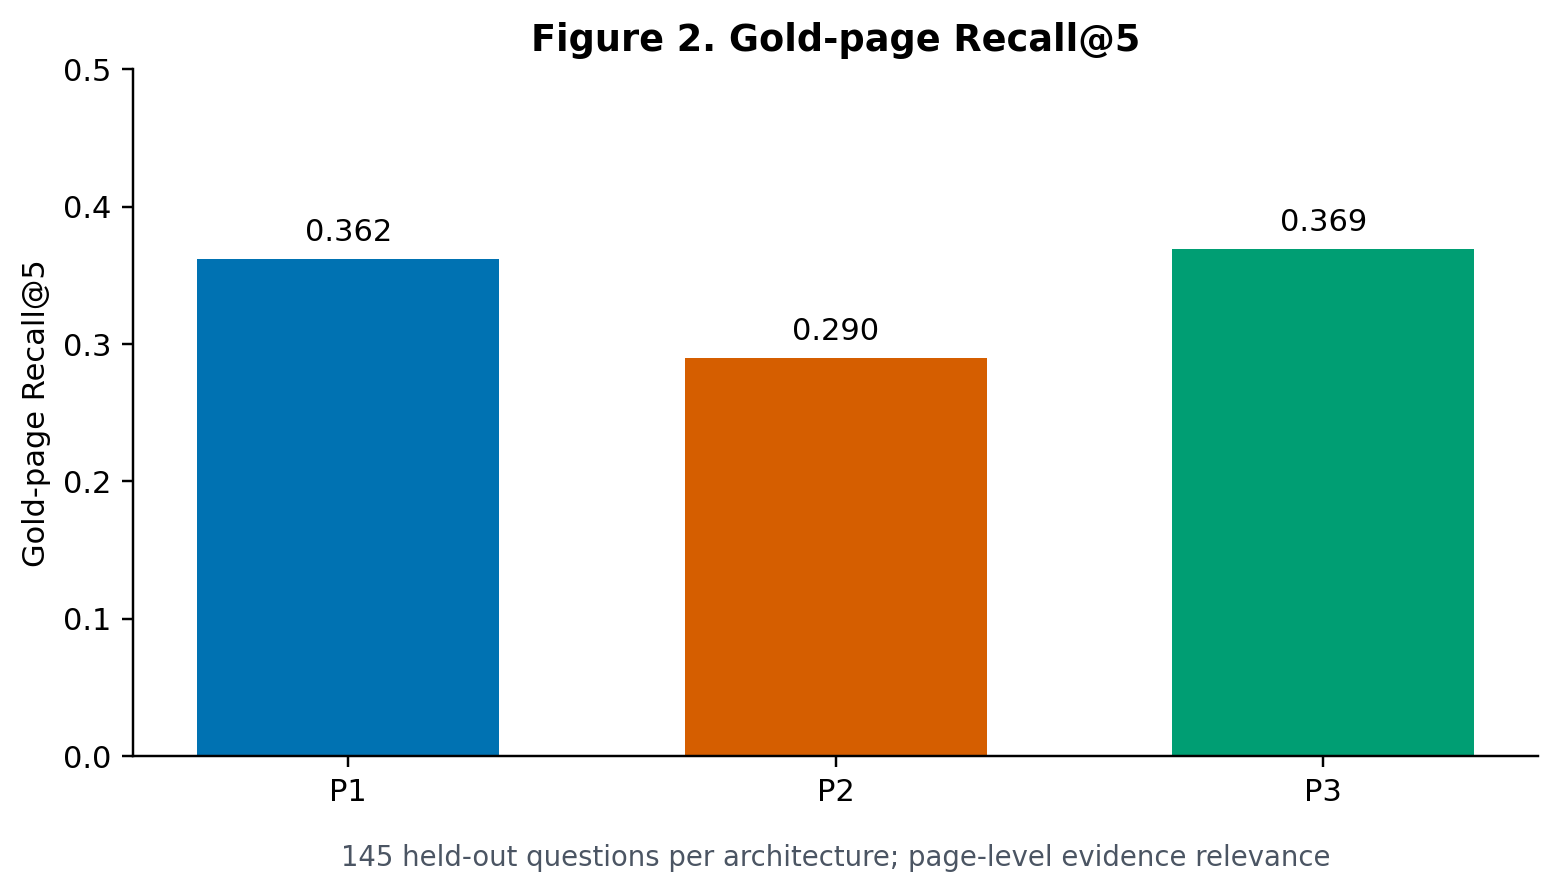

## Answer correctness (Stage 16 v2)

Exact match and token F1 are strict surface comparisons. Numeric values are normalized, but the v2 correction prevents the company name `3M` from being read as 3 million. Numeric scores have their own applicable denominator.

,architecture,question_count,numeric_applicable_count,exact_match,token_f1,numeric_accuracy,numeric_precision,numeric_recall,numeric_f1
0,P0,145,112,0.007,0.172,0.056,0.051,0.056,0.048
1,P1,145,112,0.014,0.159,0.182,0.123,0.182,0.130
2,P2,145,112,0.007,0.166,0.190,0.130,0.190,0.137
3,P3,145,112,0.007,0.170,0.176,0.114,0.176,0.127


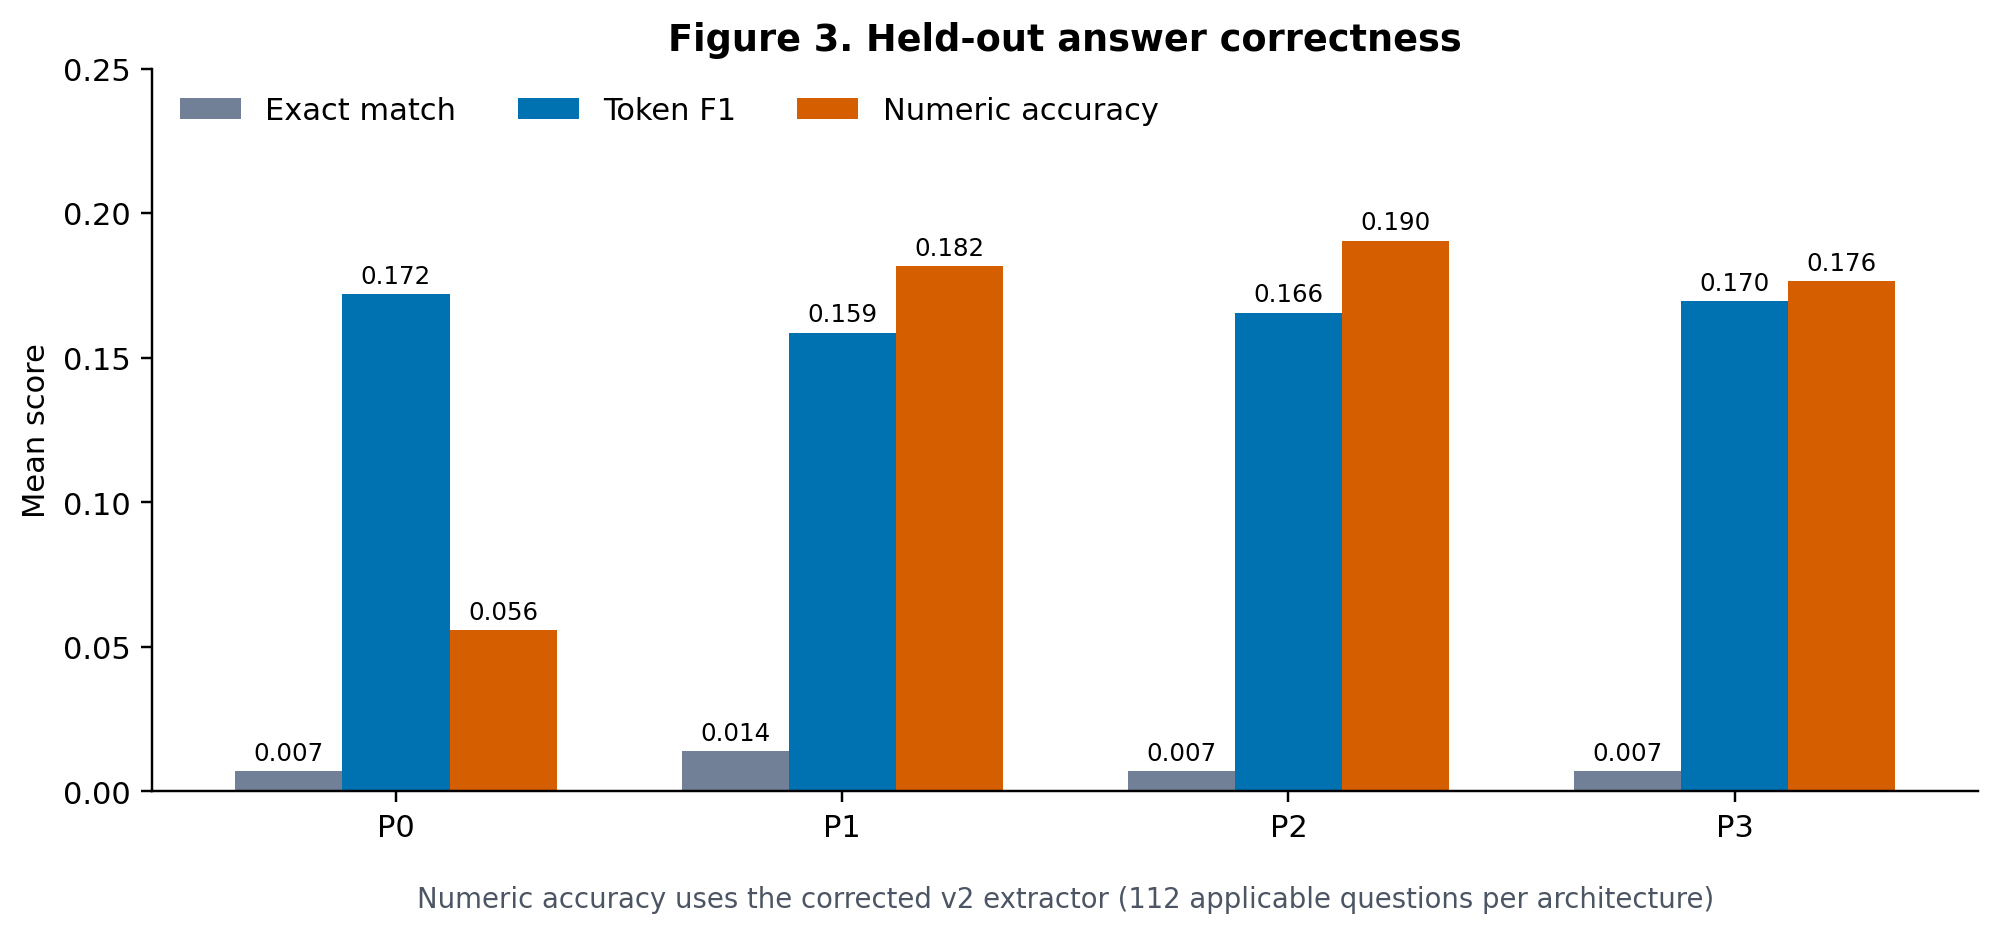

In [4]:
report.show('retrieval')
report.show('answers')

## 4. Evidence support, hallucination, and abstention

One fixed judge scores answer units against the final retrieved chunks and annotated gold evidence. This is a model-assisted measure, not verified ground truth. Interpret support alongside exact abstentions, scored-answer coverage, and the manual audit later in this notebook.

## Evidence support and hallucination (Stage 17)

One fixed `gpt-4o-mini` judge and `answer-unit-passage-v4` rubric evaluated P0-P3. Context support uses the final retrieved chunks (P1-P3); gold support uses FinanceBench annotated evidence (P0-P3). Hallucination is one minus support for scored answers. Exact abstentions and answers with no scored factual units are not assigned zero support.

,architecture,question_count,abstention_count,context_applicable_count,context_faithfulness,context_hallucination,gold_applicable_count,gold_evidence_support,gold_evidence_hallucination,judge_model,judge_protocol,context_guard_override_count,gold_guard_override_count
0,P0,145,0,0,NaN,NaN,112,0.583,0.417,gpt-4o-mini,answer-unit-passage-v4,0,82
1,P1,145,58,85,0.850,0.150,83,0.636,0.364,gpt-4o-mini,answer-unit-passage-v4,38,62
2,P2,145,63,80,0.820,0.180,81,0.621,0.379,gpt-4o-mini,answer-unit-passage-v4,37,57
3,P3,145,58,86,0.832,0.168,85,0.652,0.348,gpt-4o-mini,answer-unit-passage-v4,35,54


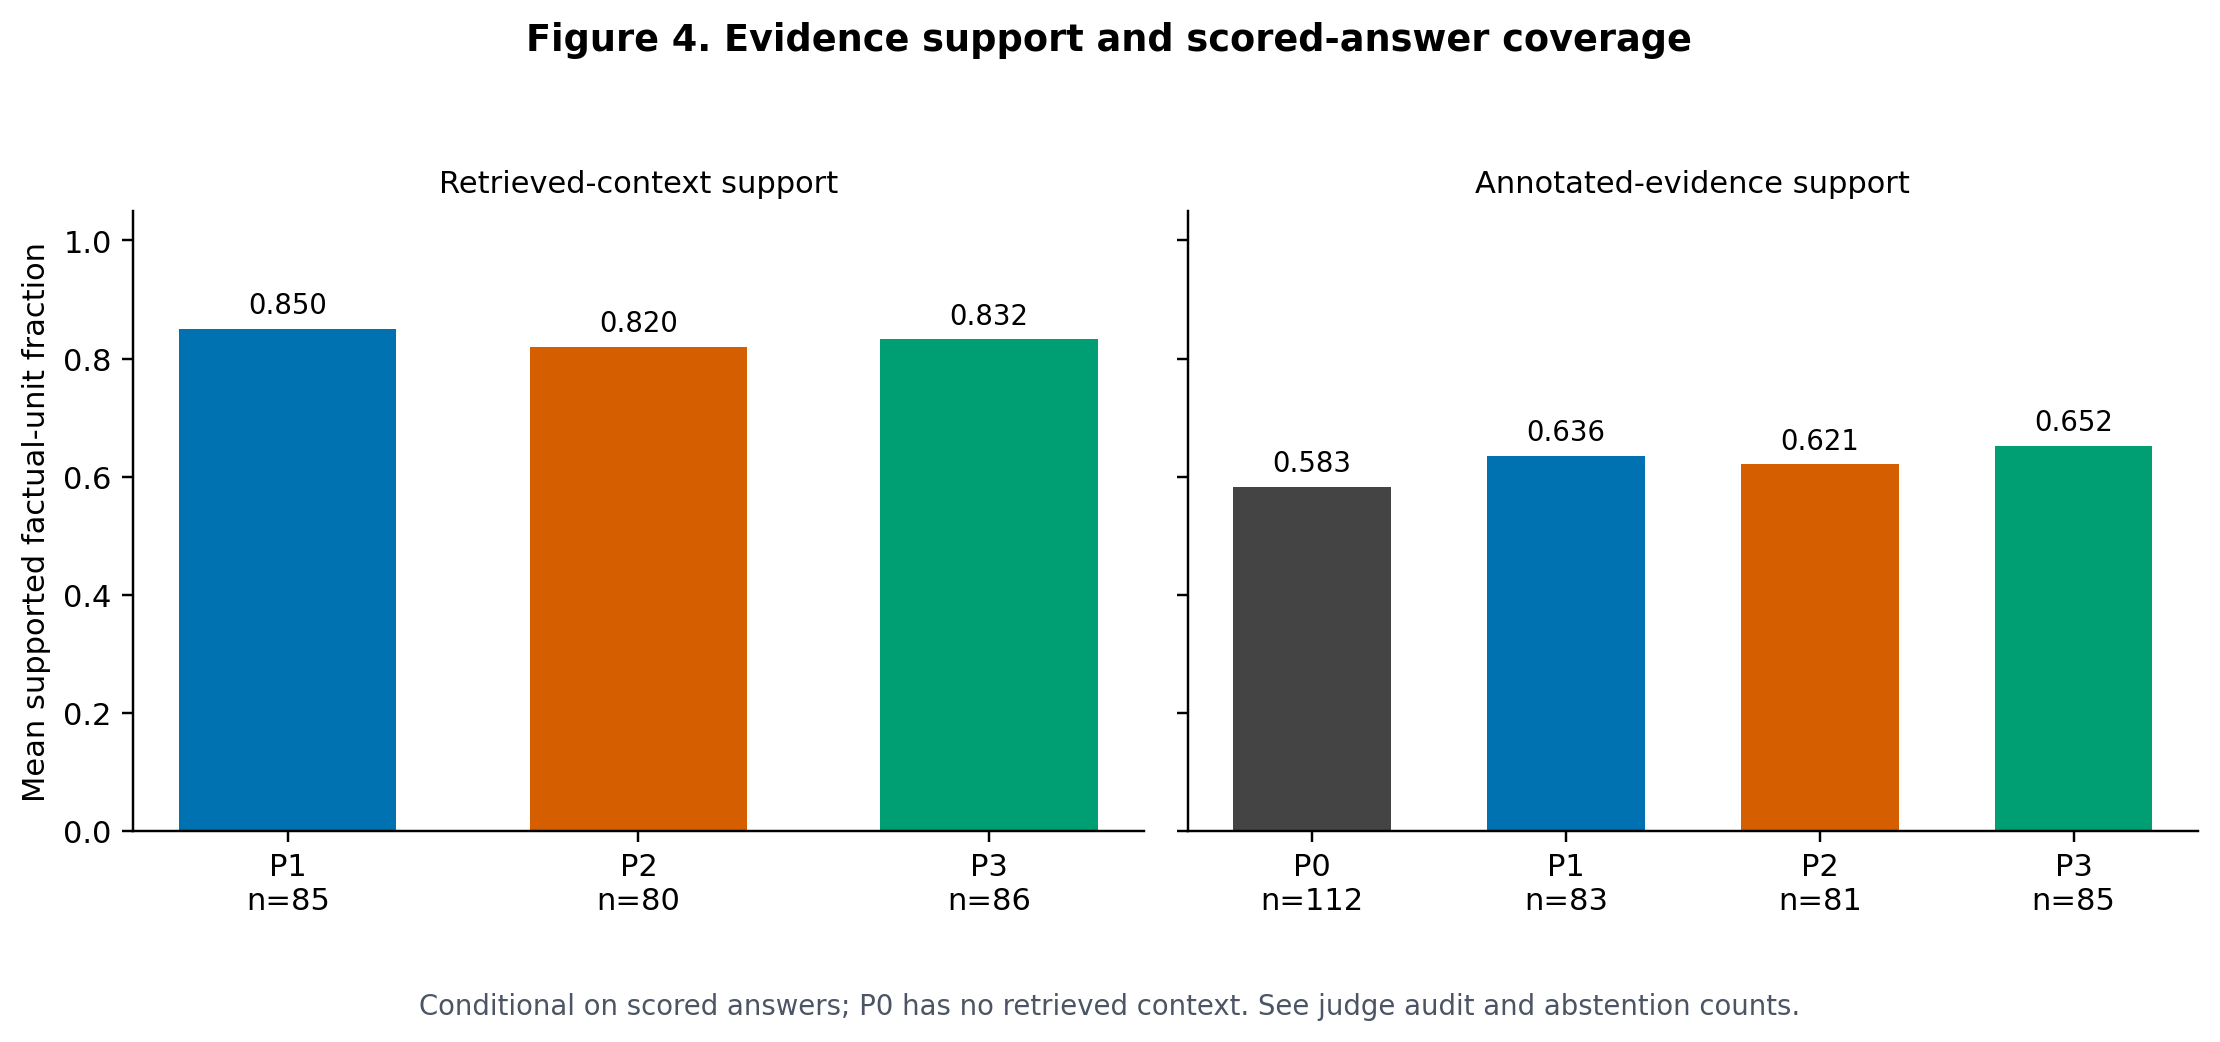

In [5]:
report.show('faithfulness')

## 5. Latency and native question categories

Latency is recorded per question, excluding initialization; separate dense/BM25/fusion sub-times were not recorded. Category analysis uses the benchmark's native labels only. Reasoning labels cover fewer than all held-out questions.

## Recorded latency (Stage 18)

Component, mean, median, standard deviation, minimum, and maximum are in milliseconds. Inapplicable components are NA; dense/BM25/fusion sub-times were not recorded separately. Setup is excluded, but API/network effects remain.

,architecture,component,question_count,mean_ms,median_ms,std_ms,min_ms,max_ms
0,P0,generation,145,2073.978,1916.465,1005.903,667.023,7214.388
1,P0,total,145,2073.983,1916.470,1005.903,667.028,7214.396
2,P1,retrieval,145,85.649,74.955,32.881,0.404,234.121
3,P1,generation,145,1847.162,1699.031,851.035,722.040,4562.680
4,P1,total,145,1932.881,1794.853,852.527,722.624,4669.682
5,P2,retrieval,145,460.561,431.851,199.320,130.682,1171.709
6,P2,generation,145,1785.003,1662.680,751.044,767.066,4215.165
7,P2,total,145,2245.601,2176.371,777.457,1051.978,4669.133
8,P3,retrieval,145,466.490,426.413,213.754,141.558,1601.398
9,P3,reranking,145,3366.415,3456.159,495.944,0.001,4314.039


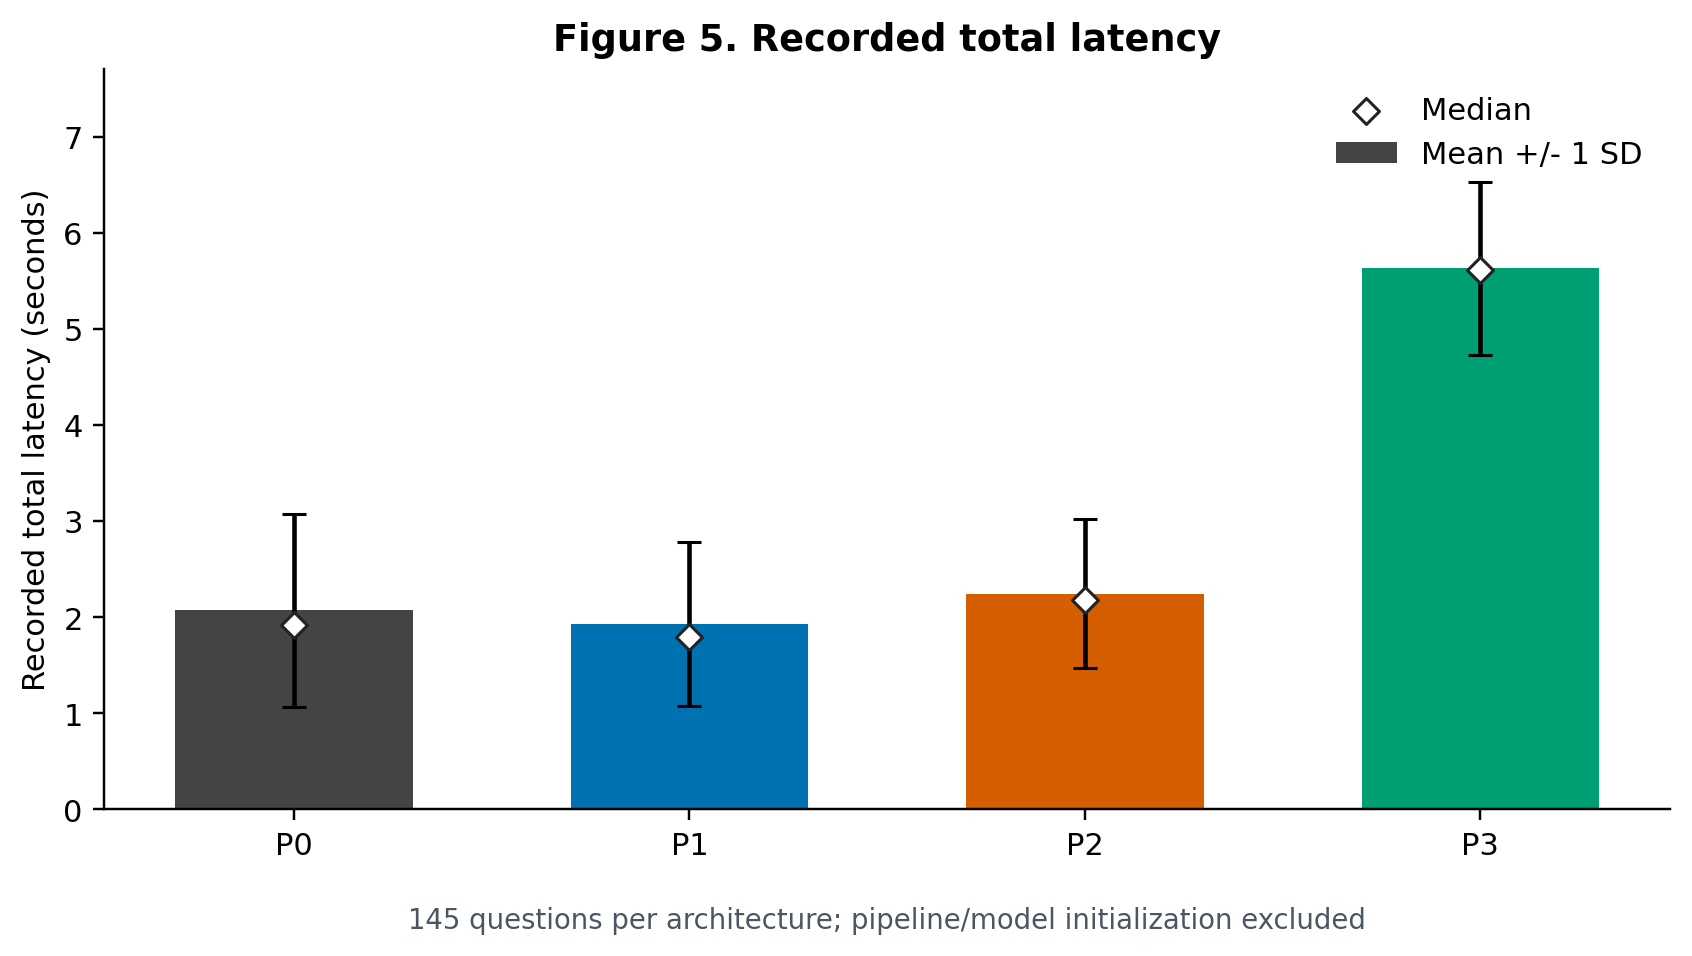

## Native FinanceBench categories (Stage 19)

`question_type` labels cover 145 questions; `question_reasoning` labels cover 96. The remaining reasoning labels are source-null and excluded only from reasoning groups. No outcome-informed derived labels were created.

### Question type

,grouping,category,architecture,question_count,token_f1_mean,numeric_accuracy_mean,numeric_accuracy_n,recall_at_5_mean,context_faithfulness_mean,context_faithfulness_n,gold_evidence_support_mean,gold_evidence_support_n,total_latency_ms_mean
0,question_type,domain-relevant,P0,48,0.229,0.070,32,NaN,NaN,0,0.713,39,2022.361
1,question_type,domain-relevant,P1,48,0.219,0.094,32,0.333,0.923,27,0.696,25,1787.056
2,question_type,domain-relevant,P2,48,0.226,0.172,32,0.240,0.926,28,0.599,28,2223.766
3,question_type,domain-relevant,P3,48,0.237,0.133,32,0.365,0.893,30,0.661,29,5701.264
4,question_type,metrics-generated,P0,48,0.000,0.021,48,NaN,NaN,0,0.353,33,2568.319
5,question_type,metrics-generated,P1,48,0.004,0.229,48,0.302,0.746,24,0.598,24,2073.728
6,question_type,metrics-generated,P2,48,0.003,0.167,48,0.198,0.581,19,0.542,20,2443.517
7,question_type,metrics-generated,P3,48,0.001,0.167,48,0.281,0.694,22,0.612,22,5930.249
8,question_type,novel-generated,P0,49,0.284,0.094,32,NaN,NaN,0,0.646,40,1640.304
9,question_type,novel-generated,P1,49,0.251,0.198,32,0.449,0.866,34,0.618,34,1937.756


### Question reasoning

,grouping,category,architecture,question_count,token_f1_mean,numeric_accuracy_mean,numeric_accuracy_n,recall_at_5_mean,context_faithfulness_mean,context_faithfulness_n,gold_evidence_support_mean,gold_evidence_support_n,total_latency_ms_mean
0,question_reasoning,Information extraction,P0,29,0.155,0.100,20,NaN,NaN,0,0.348,23,1743.603
1,question_reasoning,Information extraction,P1,29,0.192,0.350,20,0.534,0.889,21,0.632,19,1857.943
2,question_reasoning,Information extraction,P2,29,0.205,0.300,20,0.466,0.900,20,0.625,20,2288.403
3,question_reasoning,Information extraction,P3,29,0.208,0.300,20,0.569,0.904,23,0.712,22,5491.431
4,question_reasoning,Information extraction OR Logical reasoning,P0,1,0.366,0.000,1,NaN,NaN,0,0.750,1,2070.708
5,question_reasoning,Information extraction OR Logical reasoning,P1,1,0.407,0.000,1,0.000,1.000,1,1.000,1,1140.210
6,question_reasoning,Information extraction OR Logical reasoning,P2,1,0.289,0.000,1,0.000,1.000,1,0.000,1,1895.651
7,question_reasoning,Information extraction OR Logical reasoning,P3,1,0.394,0.000,1,0.000,1.000,1,0.500,1,6043.929
8,question_reasoning,Information extraction OR Logical reasoning OR,P0,1,0.353,NaN,0,NaN,NaN,0,1.000,1,2025.241
9,question_reasoning,Information extraction OR Logical reasoning OR,P1,1,0.216,NaN,0,1.000,1.000,1,1.000,1,2486.984


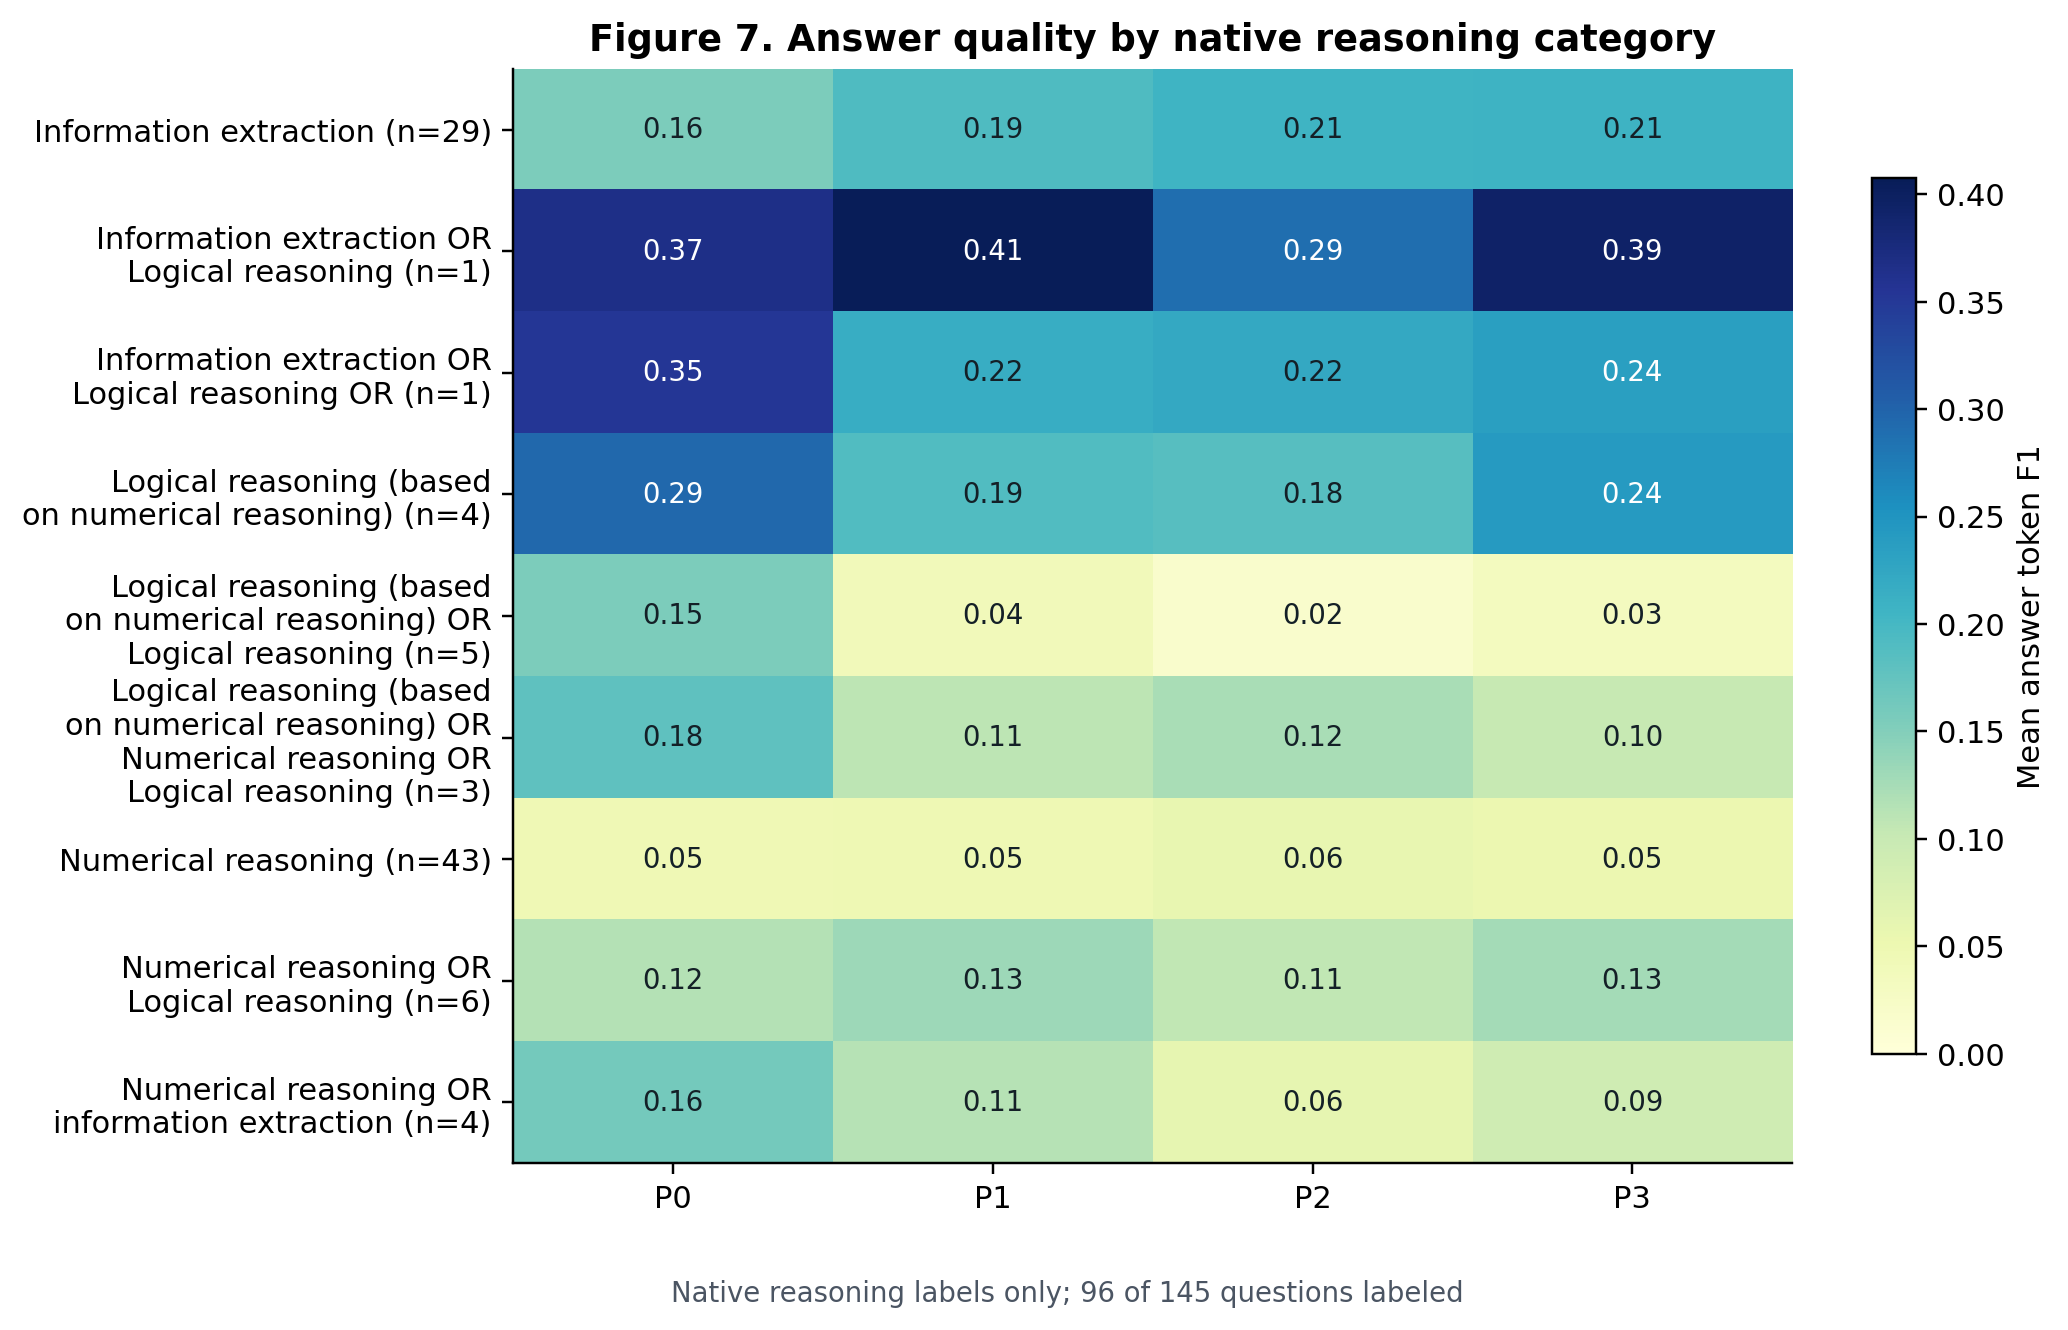

In [6]:
report.show('latency')
report.show('categories')

## 6. H0-H3 paired tests and quality-latency trade-offs

Every architecture answered the same question IDs. The tests use paired observations and a global Holm correction; support comparisons require non-NA scores on both sides. Pareto membership is descriptive and does not imply a statistically superior architecture.

## Paired hypothesis analysis (Stage 20)

These H0-H3 labels name the dissertation's substantive predictions, not statistical nulls. Every contrast pairs the same question IDs. McNemar exact handles binary outcomes; Wilcoxon signed-rank handles scores; mean differences have seeded paired-bootstrap 95% intervals. Holm adjustment spans all 21 comparisons. Scored-answer tests use complete pairs only.

,Hypothesis,Substantive prediction,Primary contrast
0,H0,"Closed-book P0 has most hallucination, least accuracy, and lowest latency.",P0 versus P1-P3
1,H1,Dense P1 improves faithfulness over P0 but may miss exact terms/numbers.,P0 versus P1
2,H2,Hybrid P2 improves retrieval on numeric/terminology-heavy questions.,P1 versus P2
3,H3,Reranked hybrid P3 improves text-based faithfulness at a latency cost.,P2 versus P3


,hypothesis,architecture_a,architecture_b,metric,population,test,pair_count,excluded_pair_count,mean_difference_b_minus_a,difference_ci95_low,difference_ci95_high,p_value_two_sided,holm_p_value,significant_holm_0_05,rank_biserial_b_minus_a,a_only_success,b_only_success
0,"H0,H1",P0,P1,gold_evidence_support,scored_units_only,"Wilcoxon signed-rank, two-sided",66,79,0.083,-0.071,0.234,0.366,1.000,0,0.155,NaN,NaN
1,H0,P0,P2,gold_evidence_support,scored_units_only,"Wilcoxon signed-rank, two-sided",63,82,0.049,-0.116,0.212,0.588,1.000,0,0.095,NaN,NaN
2,H0,P0,P3,gold_evidence_support,scored_units_only,"Wilcoxon signed-rank, two-sided",69,76,0.141,-0.011,0.288,0.074,0.888,0,0.310,NaN,NaN
3,H0,P0,P1,exact_match,all_questions,"McNemar exact, two-sided",145,0,0.007,0.000,0.021,1.000,1.000,0,NaN,0.0,1.0
4,H0,P0,P1,token_f1,all_questions,"Wilcoxon signed-rank, two-sided",145,0,-0.013,-0.035,0.009,0.170,1.000,0,-0.160,NaN,NaN
5,H0,P0,P1,numeric_accuracy,gold_numeric_questions,"Wilcoxon signed-rank, two-sided",112,33,0.126,0.051,0.202,0.002,0.030,1,0.696,NaN,NaN
6,H0,P0,P1,total_latency_ms,all_questions,"Wilcoxon signed-rank, two-sided",145,0,-141.102,-348.994,62.631,0.307,1.000,0,-0.098,NaN,NaN
7,H0,P0,P2,exact_match,all_questions,"McNemar exact, two-sided",145,0,0.000,0.000,0.000,1.000,1.000,0,NaN,0.0,0.0
8,H0,P0,P2,token_f1,all_questions,"Wilcoxon signed-rank, two-sided",145,0,-0.006,-0.034,0.020,0.373,1.000,0,-0.105,NaN,NaN
9,H0,P0,P2,numeric_accuracy,gold_numeric_questions,"Wilcoxon signed-rank, two-sided",112,33,0.135,0.052,0.219,0.003,0.057,0,0.590,NaN,NaN


## Unweighted quality-latency trade-offs (Stage 21)

The Pareto views maximize one quality score and minimize mean total latency; no arbitrary weighted score is used. Filled points are nondominated point estimates. Conditional support coverage and abstentions must be considered with those flags.

,architecture,question_count,exact_abstention_count,exact_abstention_rate,answer_token_f1_mean,numeric_accuracy_mean,numeric_accuracy_n,hit_at_5_mean,recall_at_5_mean,mrr_at_5_mean,retrieval_n,context_faithfulness_mean,context_faithfulness_n,gold_evidence_support_mean,gold_evidence_support_n,total_latency_mean_ms,total_latency_median_ms,pareto_answer_token_f1,pareto_context_faithfulness,pareto_recall_at_5,pareto_gold_evidence_support
0,P0,145,0,0.000,0.172,0.056,112,NaN,NaN,NaN,0,NaN,0,0.583,112,2073.983,1916.470,1,NaN,NaN,0
1,P1,145,58,0.400,0.159,0.182,112,0.400,0.362,0.221,145,0.850,85,0.636,83,1932.881,1794.853,1,1.0,1.0,1
2,P2,145,63,0.434,0.166,0.190,112,0.317,0.290,0.174,145,0.820,80,0.621,81,2245.601,2176.371,0,0.0,0.0,0
3,P3,145,58,0.400,0.170,0.176,112,0.400,0.369,0.284,145,0.832,86,0.652,85,5632.504,5618.543,0,0.0,1.0,1


,objective,architecture,quality_mean,quality_scored_n,quality_coverage_rate,exact_abstention_rate,mean_total_latency_ms,pareto_nondominated,dominated_by
0,answer_token_f1,P0,0.172,145,1.000,0.000,2073.983,1,NaN
1,answer_token_f1,P1,0.159,145,1.000,0.400,1932.881,1,NaN
2,answer_token_f1,P2,0.166,145,1.000,0.434,2245.601,0,P0
3,answer_token_f1,P3,0.170,145,1.000,0.400,5632.504,0,P0
4,context_faithfulness,P1,0.850,85,0.586,0.400,1932.881,1,NaN
5,context_faithfulness,P2,0.820,80,0.552,0.434,2245.601,0,P1
6,context_faithfulness,P3,0.832,86,0.593,0.400,5632.504,0,P1
7,recall_at_5,P1,0.362,145,1.000,0.400,1932.881,1,NaN
8,recall_at_5,P2,0.290,145,1.000,0.434,2245.601,0,P1
9,recall_at_5,P3,0.369,145,1.000,0.400,5632.504,1,NaN


### Adjacent-architecture differences on shared applicable questions

,architecture_a,architecture_b,metric,pair_count,excluded_pair_count,mean_a_paired,mean_b_paired,mean_difference_b_minus_a,percent_change_from_a
0,P0,P1,token_f1,145,0,0.172,0.159,-0.013,NaN
1,P0,P1,numeric_accuracy,112,33,0.056,0.182,0.126,NaN
2,P0,P1,gold_evidence_support,66,79,0.542,0.625,0.083,NaN
3,P0,P1,total_latency_ms,145,0,2073.983,1932.881,-141.102,-6.803
4,P0,P1,abstained,145,0,0.000,0.400,0.400,NaN
5,P1,P2,token_f1,145,0,0.159,0.166,0.007,NaN
6,P1,P2,numeric_accuracy,112,33,0.182,0.190,0.009,NaN
7,P1,P2,gold_evidence_support,71,74,0.645,0.631,-0.014,NaN
8,P1,P2,context_faithfulness,73,72,0.873,0.831,-0.042,NaN
9,P1,P2,recall_at_5,145,0,0.362,0.290,-0.072,NaN


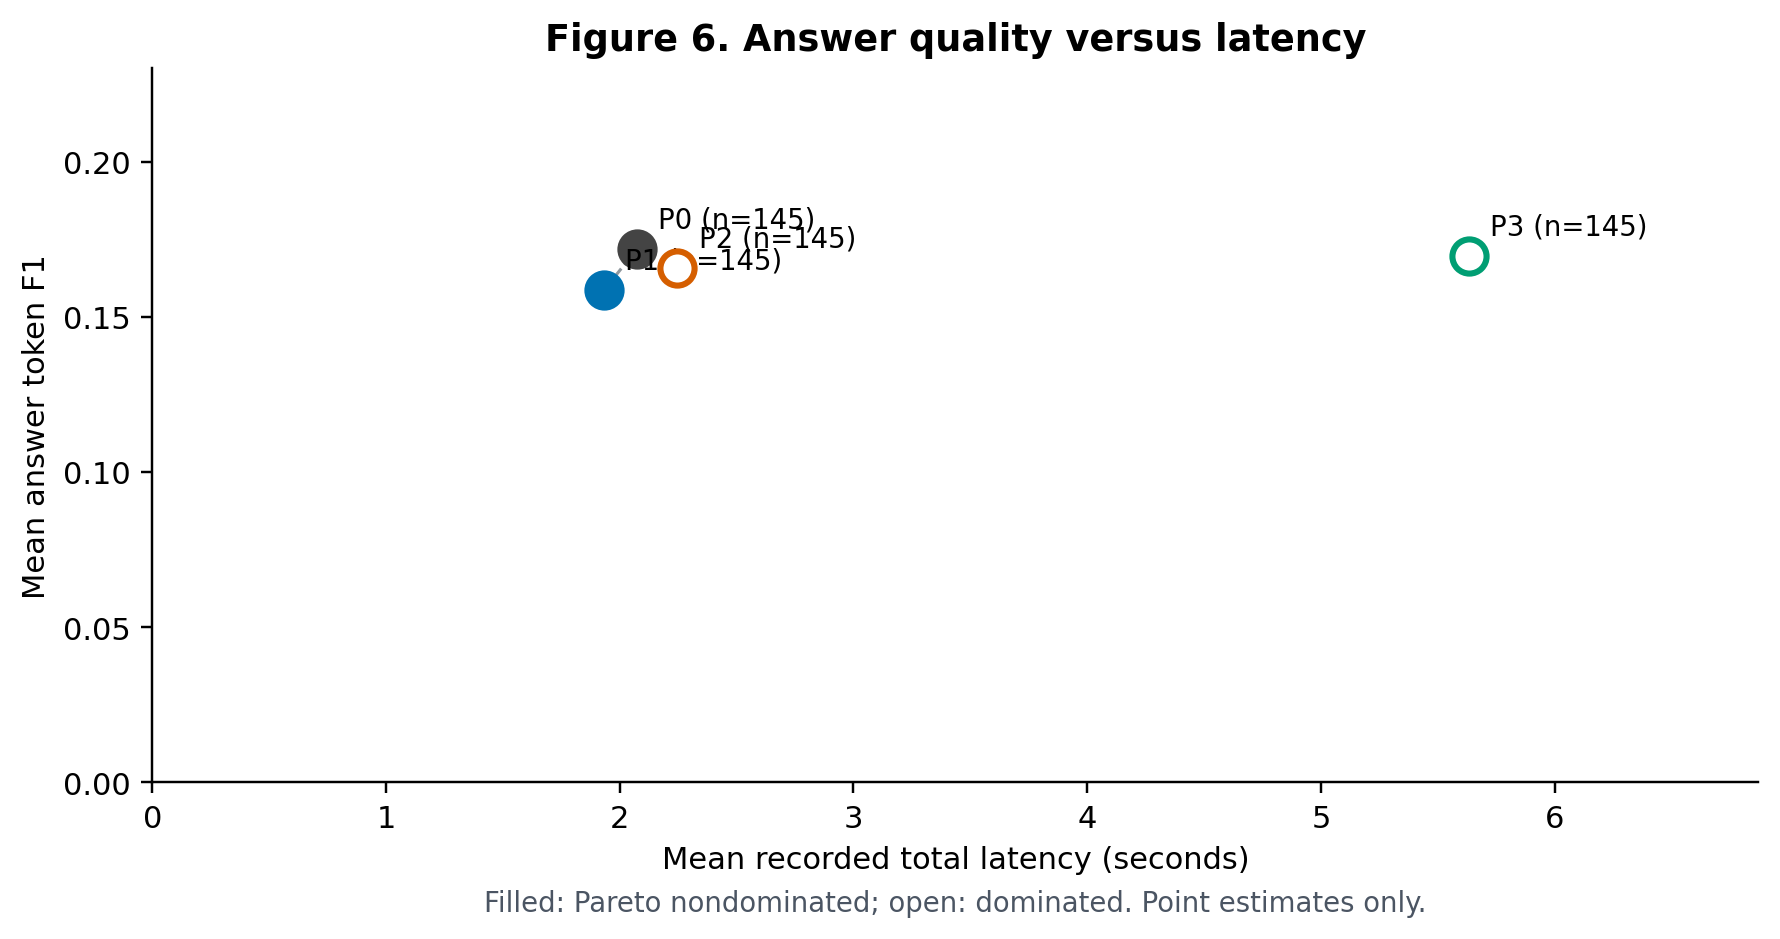

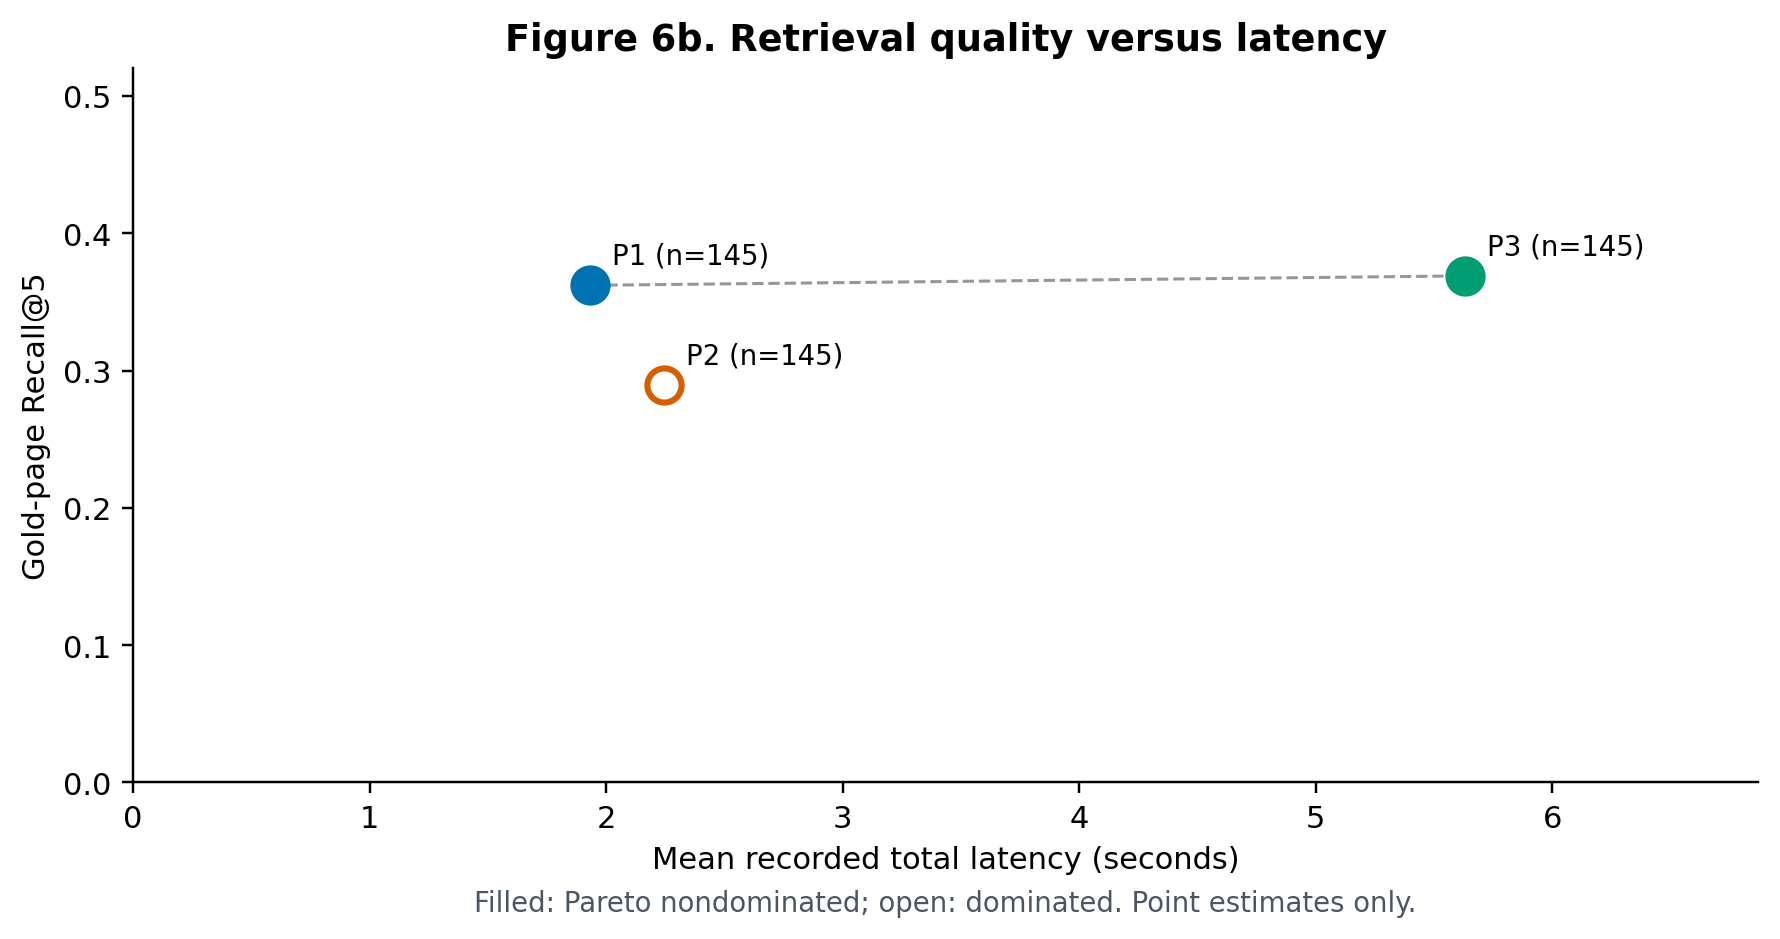

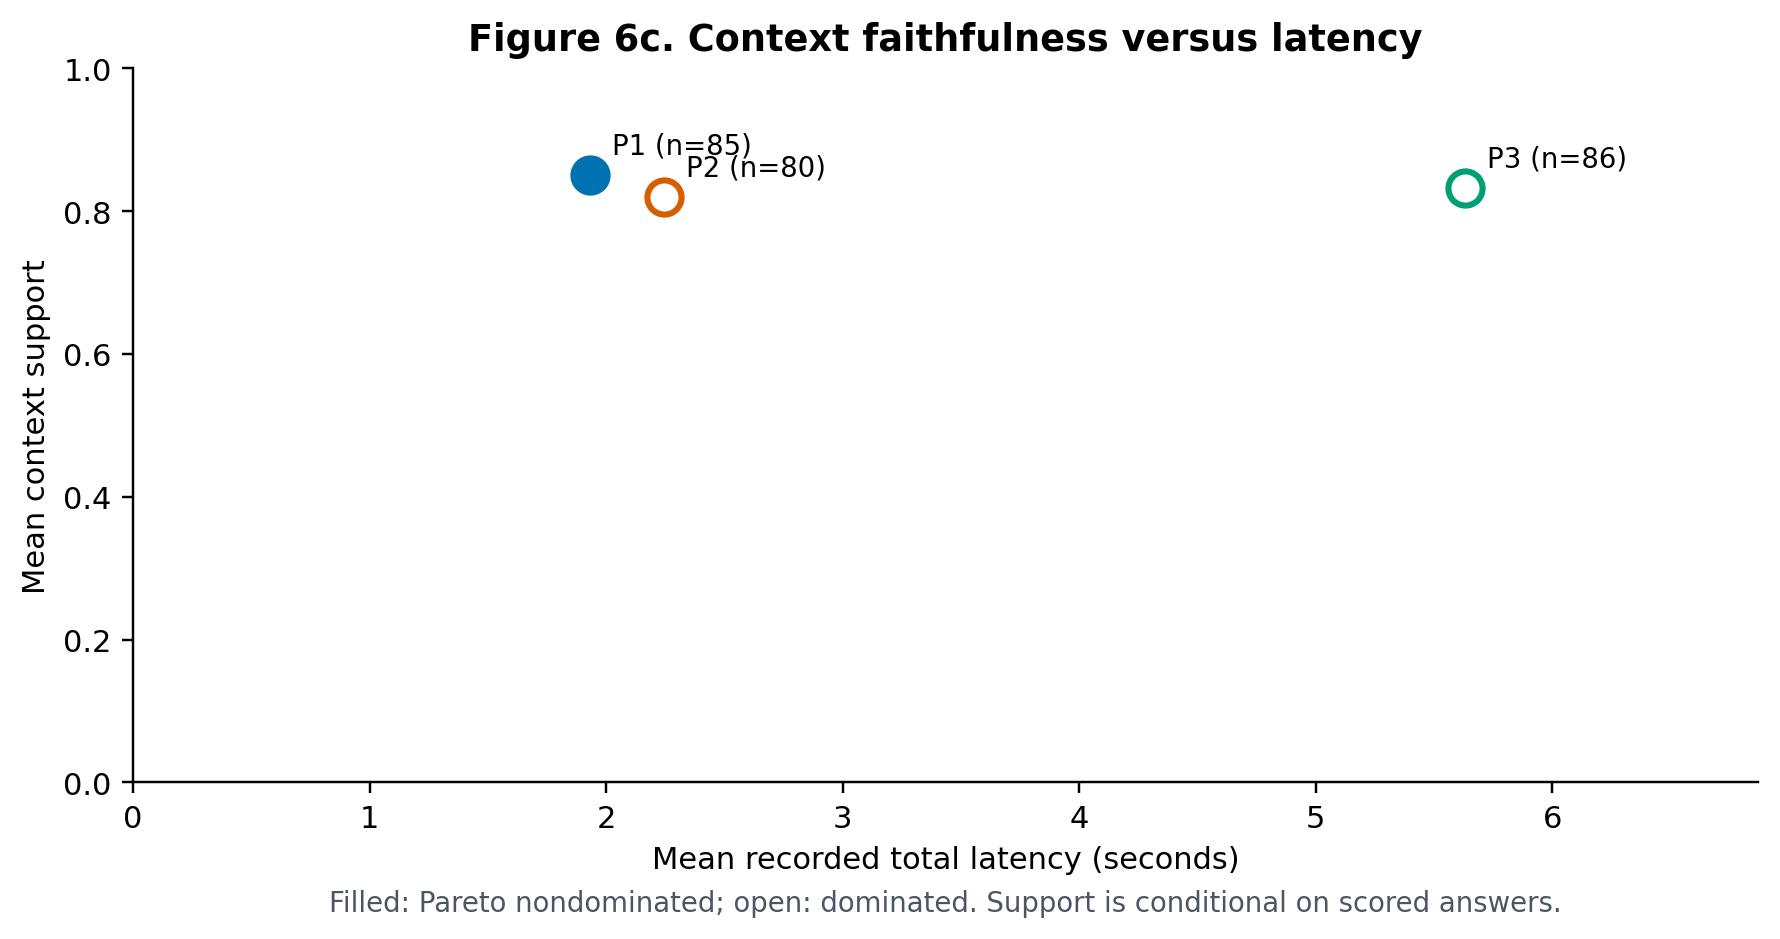

In [7]:
report.show('statistics')
report.show('tradeoffs')

## 7. Audit examples and cautious interpretation

The audit sample was chosen by question ID before its v4 judgments were inspected. It reveals both an incorrect adjacent-year table value marked supported and a missed unsupported closed-book answer. The cases are diagnostic, not an error-rate estimate. The closing interpretation therefore stops short of claiming a universal winner.

In [8]:
report.show('audit')
report.show('interpretation')

## Preselected evidence-judge audit

Eight non-pilot questions were selected by a hash of IDs before per-question v4 judgments were read. These cases are illustrative and not an estimated judge-error rate.

,question_id,question,gold_answer
0,financebench_id_10285,We need to calculate a financial metric by using information only provided within the balance sh...,$12645.00
1,financebench_id_03849,What is the FY2018 - FY2020 3 year average of capex as a % of revenue for MGM Resorts? Answer in...,7.9%
2,financebench_id_04854,"According to the information provided in the statement of cash flows, what is the FY2020 free ca...",$3215.00
3,financebench_id_01935,What was the key agenda of the AMCOR's 8k filing dated 1st July 2022?,"Amcor Finance (USA), Inc. and Amcor Flexibles North America, Inc., entered into supplemental ind..."
4,financebench_id_10130,"Based on the information provided primarily in the balance sheet and the statement of income, wh...",63.86
5,financebench_id_01009,What are the geographies that Pepsico primarily operates in as of FY2022?,"As of FY2022, Pepsico primarily operates in the following geographies: North America, Latin Amer..."
6,financebench_id_00476,Which debt securities are registered to trade on a national securities exchange under American E...,There are none
7,financebench_id_01912,Which region had the worst topline performance for MGM during FY2022?,MGM China experienced the worst topline performance amongst the other regions presented. Its rev...


# Stage 17: Preselected v4 Judgment Audit

## Scope

The eight question IDs were fixed in `faithfulness_audit_selection.json` by a
hash of IDs before individual v4 judgments were inspected. This excludes the
five pilot questions used while developing the judge. The sample covers 32
P0-P3 answers and their 56 gold/context judgment records (P0 has no context
judgment). Answers, cited unit decisions, and the annotated evidence text were
checked against the frozen source. This is a qualitative spot check, not an
estimate of judge error prevalence or a replacement for a full human review.

| Question ID | Manual observation |
| --- | --- |
| `financebench_id_10285` | **Clear false positive.** Boeing's FY2018 PP&E is $12,645 million, while $12,672 million is the FY2017 column in the same balance-sheet row. P3 answered $12,672 million. The v4 judge marked this unit supported against both gold evidence and retrieved context because the number occurs in the cited table; the numeric-presence guard did not check column-year alignment. P1/P2 answered $12,645 million. |
| `financebench_id_03849` | P1/P3 abstained. P2's longer answer ended with "Insufficient evidence in the retrieved context." The gold-evidence judge marked that sentence as a supported factual unit, even though the annotated statements contain the inputs for the 7.9% answer. The exact-abstention rule did not classify this mixed answer as an abstention. P0 supplied no result and had no scored factual units. |
| `financebench_id_04854` | P1-P3 answered $3,215.4 million for General Mills FY2020 free cash flow. The annotated cash-flow statement gives 3,676.2 less 460.8 = 3,215.4; the gold answer is rounded to $3,215.00. Support is reasonable, while strict numeric equality may penalize the rounding difference. P0 gave no number. |
| `financebench_id_01935` | P0 described an acquisition that is not the filing's agenda and was marked unsupported. P1 abstained. P2/P3 identified the Amcor supplemental indentures, consistent with the annotated filing, and were marked supported. |
| `financebench_id_10130` | All retrieval systems abstained on Corning DPO despite a numerical gold answer. P0 restated the formula and requested input values; its two generic operand descriptions were marked gold-supported, although it never answered 63.86. This illustrates that evidence support is not answer completeness. |
| `financebench_id_01009` | The generated PepsiCo geography lists are partial or use different granularity from the gold list. Some were marked context-supported while gold support was NA or lower. A faithful statement about selected countries does not necessarily answer the requested complete geographic scope. |
| `financebench_id_00476` | The annotated filing lists no registered debt securities. P0 invented generic senior notes/bonds, but the judge labeled its three answer units nonfactual and assigned no gold-support score: a **clear missed hallucination**. P1-P3 abstained despite the evidence supporting "none." |
| `financebench_id_01912` | P1-P3 identified MGM China and the 44% revenue decline, consistent with the annotated evidence. P0 said "Asia-Pacific" instead of the named MGM China region, yet was marked supported; this is at least an imprecise entity match. |

## Interpretation

Table F1 is a **model-assisted unit-level evidence-support measure**, not an
independently verified accuracy or hallucination ground truth. Its rates are
conditional on non-abstaining answers with factual units and must be read with
abstention counts. The audit found both false support (notably adjacent-year
table columns) and missed factual claims, so small differences among P1-P3
faithfulness means are not by themselves decisive. Keep the v4 journal,
per-question metrics, and aggregate table unchanged; do not tune the judge
against this held-out sample and mix a new protocol into the frozen run.


### financebench_id_10285

**Question:** We need to calculate a financial metric by using information only provided within the balance sheet. Please answer the following question: what is Boeing's year end FY2018 net property, plant, and equipment (in USD millions)?

**Gold:** $12645.00

,architecture,generated_answer,final_chunk_ids,final_pages,hit_at_5,token_f1,numeric_accuracy,context_faithfulness,gold_evidence_support,abstained,total_latency_ms
0,P0,"Boeing's year end FY2018 net property, plant, and equipment was $82,889 million.",,,<NA>,0.0,0.0,NaN,0.0,0,1524.394
1,P1,"Boeing's year-end FY2018 net property, plant, and equipment is $12,645 million.",BOEING_2018_10K_p84_c000; BOEING_2018_10K_p71_c000; BOEING_2018_10K_p52_c000; BOEING_2018_10K_p84_c001; BOEING_2018_10K_p70_c000,BOEING_2018_10K p84; BOEING_2018_10K p71; BOEING_2018_10K p52; BOEING_2018_10K p84; BOEING_2018_10K p70,0,0.0,1.0,1.0,1.0,0,1477.696
2,P2,"Boeing's year-end FY2018 net property, plant, and equipment is $12,645 million.",BOEING_2018_10K_p109_c000; BOEING_2018_10K_p63_c000; BOEING_2018_10K_p84_c000; BOEING_2018_10K_p71_c000; BOEING_2018_10K_p52_c000,BOEING_2018_10K p109; BOEING_2018_10K p63; BOEING_2018_10K p84; BOEING_2018_10K p71; BOEING_2018_10K p52,0,0.0,1.0,1.0,1.0,0,2476.392
3,P3,"Boeing's year end FY2018 net property, plant, and equipment is $12,672 million.",BOEING_2018_10K_p63_c001; BOEING_2018_10K_p95_c000; BOEING_2018_10K_p70_c000; BOEING_2018_10K_p63_c000; BOEING_2018_10K_p48_c000,BOEING_2018_10K p63; BOEING_2018_10K p95; BOEING_2018_10K p70; BOEING_2018_10K p63; BOEING_2018_10K p48,0,0.0,0.0,1.0,1.0,0,5922.688


## Reading the results

- **H0 (closed book):** P0's mean total latency was 2.07 s, versus 1.93 s for P1. Thus P0 was not the fastest observed architecture. Its gold-evidence support mean was 0.583 (n=112), with the judge caveats above.
- **H1 (dense RAG):** P1 improved strict numeric accuracy over P0, but the paired gold-support difference was not significant after Holm adjustment. Its mean answer token F1 was not higher than P0's.
- **H2 (hybrid):** P2 Recall@5 was 0.290, below P1's 0.362; the paired difference was -0.072 (Holm p=0.184). This run does not establish the proposed hybrid retrieval advantage.
- **H3 (reranking):** P3 added 3.39 s per question versus P2 (Holm-adjusted p<0.001), while the paired context-support difference was +0.013 over 71 scored pairs (Holm p=1.000). The evidence does not establish a faithfulness gain commensurate with that cost.
- **Design choice:** Point-estimate context-support/latency frontier: P1; Recall@5/latency frontier: P1, P3. These are different objectives, and no single scalar score or definitive winner is imposed. Consider the audit, abstentions, and practical latency limit in the discussion.

## Interpretation safeguards

- **Support is model-assisted, not ground truth.** The fixed `gpt-4o-mini` v4 judge scored factual answer units. The preselected eight-question audit found a clear wrong-year Boeing table value marked supported and an invented P0 answer marked nonfactual. See `results/evaluation/faithfulness_audit_report.md`.
- **Abstentions are not zeros.** Context/gold support means include only answers with scored factual units. Show their `n` and the exact-abstention count alongside the means. P0 has no context score.
- **Surface metrics are strict.** Exact match and token F1 can penalize correct paraphrases. Numeric accuracy uses the corrected v2 extractor; abbreviated dates remain a known limitation.
- **Latency is observational.** Recorded per-question time excludes setup but includes API/network variation. Sequential architecture runs do not isolate a pure causal hardware cost.
- **Subgroup coverage is incomplete.** Native `question_reasoning` exists for 96/145 questions. No numeric/terminology flags were assigned after viewing outcomes.
- **Stage 20 was not blinded preregistration.** The comparison list was fixed before its tests ran, but earlier held-out aggregate results were visible. The 21 p-values use a global Holm adjustment. Nonsignificance does not prove equivalence.
- **Pareto membership is descriptive.** It uses point-estimate mean quality and latency without subjective weights; differing scored-answer coverage matters.

## Further inspection

For another frozen question, call `report.show_case(question_id)`. Each section also has a DataFrame method (`report.retrieval()`, `report.answers()`, `report.faithfulness()`, `report.latency()`, `report.categories()`, `report.hypothesis_tests()`, `report.frontiers()`) for custom analysis. Keep any exploratory findings separate from the frozen confirmatory tables.

In [12]:
import importlib
from pathlib import Path
import sys
from IPython.display import Markdown, display

here = Path.cwd().resolve()
repo = next((path for path in (here, *here.parents) if (path / 'scripts' / 'notebook_report.py').exists()), None)
if repo is None:
    raise FileNotFoundError('Open this notebook inside the finrag-arch-eval repository.')
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))
import scripts.notebook_report as notebook_report
importlib.reload(notebook_report)  # Refresh a helper imported before comparison_matrix was added.
report = notebook_report.load_report(repo)

display(Markdown('## Final P0-P3 comparison matrix'))
display(report.comparison_matrix().fillna('N/A'))
display(Markdown('Values are frozen-run means; proportions use 0-1 and latency is in seconds. '                 'Numeric scores use the corrected v2 evaluator. Evidence support is conditional '                 'on the scored n shown; it is not overall answer accuracy. '                 'RRF applies only to P2/P3, and the shared RAG prompt only to P1-P3.'))

## Final P0-P3 comparison matrix

Group        Shared controls                                                 \
Measure           Held-out n Corpus chunks Corpus SHA-256 (12)   Answer LLM   
Architecture                                                                  
P0                       145         24410        fa3331599807  gpt-4o-mini   
P1                       145         24410        fa3331599807  gpt-4o-mini   
P2                       145         24410        fa3331599807  gpt-4o-mini   
P3                       145         24410        fa3331599807  gpt-4o-mini   

Group                                                                  Design  \
Measure      Max output tokens          Temperature                 Retrieval   
Architecture                                                                    
P0                         256  API default (unset)               closed_book   
P1                         256  API default (unset)                     dense   
P2                         256  API default (unset)                hybrid_rrf   
P3                         256  API default (unset)  hybrid_rrf_cross_encoder   

Group                              ...    Answer        Evidence  \
Measure      Dense k BM25 k RRF k  ... Numeric n Context support   
Architecture                       ...                             
P0               N/A    N/A   N/A  ...       112             N/A   
P1                 5    N/A   N/A  ...       112            0.85   
P2                10     10    60  ...       112            0.82   
P3                20     20    60  ...       112           0.832   

Group                                                                         \
Measure      Context hallucination Context n Gold support Gold hallucination   
Architecture                                                                   
P0                             N/A         0        0.583              0.417   
P1                            0.15        85        0.636              0.364   
P2                            0.18        80        0.621              0.379   
P3                           0.168        86        0.652              0.348   

Group                                        Latency                     
Measure      Gold n Exact abstentions Mean total (s) Mean reranking (s)  
Architecture                                                             
P0              112                 0           2.07                N/A  
P1               83                58           1.93                N/A  
P2               81                63           2.25                N/A  
P3               85                58           5.63               3.37  

[4 rows x 34 columns]

Values are frozen-run means; proportions use 0-1 and latency is in seconds. Numeric scores use the corrected v2 evaluator. Evidence support is conditional on the scored n shown; it is not overall answer accuracy. RRF applies only to P2/P3, and the shared RAG prompt only to P1-P3.